**В домашней работе необходимо выполнить следующее задание:**

1. Используя предложенный [датасет](https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv) японских машин, обучите модель предсказывать цены на японские автомобили.
2. Создайте обучающую, тестовую и проверочную выборки.
3. Оцените качество работы созданной сети, определите средний процент ошибки на проверочной выборке.
4. В качестве ошибки рекомендуется использовать среднеквадратическую ошибку (mse).
5. Выполнив задание, получите 3 балла.
6. Хотите 4 балла? Добейтесь ошибки менее 10%.
7. Хотите 5 баллов? Добейтесь ошибки менее 5%.


**Примечание**. Подробную информацию о датасете можно узнать на портале соревновани [kaggle.com](https://www.kaggle.com/datasets/doaaalsenani/used-cars-dataets/data).



In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv

--2024-03-18 14:18:48--  https://storage.yandexcloud.net/academy.ai/japan_cars_dataset.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 136735 (134K) [text/csv]
Saving to: ‘japan_cars_dataset.csv’

japan_cars_dataset. 100%[===================>] 133.53K   287KB/s    in 0.5s    

2024-03-18 14:18:49 (287 KB/s) - ‘japan_cars_dataset.csv’ saved [136735/136735]



In [ ]:
import pandas as pd
cars = pd.read_csv('japan_cars_dataset.csv', sep=',')

# Удалим строки с пустыми значениями
cars = cars.dropna()

# Выводим первые 10 машин
cars.head(10)

,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline
5,5,190,daihatsu,mira,2004,81400,660,at,2wd,rhd,gasoline
6,8,220,nissan,march,2010,117000,1200,at,2wd,rhd,gasoline
7,9,230,volkswagen,passat,2008,127763,3190,at,4wd,rhd,gasoline
8,10,275,mazda,bongo van,2010,178218,1800,mt,2wd,rhd,gasoline
9,11,283,honda,step wgn,2005,121655,2000,at,2wd,rhd,gasoline


TensorFlow: 2.20.0
GPU: []
Размер датасета: (2318, 11)


,Unnamed: 0,price,mark,model,year,mileage,engine_capacity,transmission,drive,hand_drive,fuel
0,0,80,nissan,march,2003,80000,1240,at,2wd,rhd,gasoline
1,1,110,nissan,march,2010,53000,1200,at,2wd,rhd,gasoline
2,2,165,nissan,lafesta,2005,47690,2000,at,2wd,rhd,gasoline
3,3,190,toyota,avensis,2008,130661,1990,at,2wd,rhd,gasoline
4,4,190,daihatsu,mira,2006,66300,660,at,2wd,rhd,gasoline


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2318 entries, 0 to 2317
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       2318 non-null   int64 
 1   price            2318 non-null   int64 
 2   mark             2318 non-null   object
 3   model            2318 non-null   object
 4   year             2318 non-null   int64 
 5   mileage          2318 non-null   int64 
 6   engine_capacity  2318 non-null   int64 
 7   transmission     2318 non-null   object
 8   drive            2318 non-null   object
 9   hand_drive       2318 non-null   object
 10  fuel             2318 non-null   object
dtypes: int64(5), object(6)
memory usage: 199.3+ KB
Пропуски:


,0
price,0
mark,0
model,0
year,0
mileage,0
engine_capacity,0
transmission,0
drive,0
hand_drive,0
fuel,0


Размер после очистки: (2318, 10)


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       264,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 440,833 (1.68 MB)

 Trainable params: 439,041 (1.67 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/300
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.3451 - mae: 0.8843
Epoch 1: val_loss improved from None to 0.97432, saving model to /content/best_japan_cars.keras

Epoch 1: finished saving model to /content/best_japan_cars.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 1.1184 - mae: 0.8081 - val_loss: 0.9743 - val_mae: 0.7265 - learning_rate: 0.0010
Epoch 2/300
55/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.7917 - mae: 0.6754
Epoch 2: val_loss did not improve from 0.97432
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.7468 - mae: 0.6554 - val_loss: 0.9916 - val_mae: 0.7130 - learning_rate: 0.0010
Epoch 3/300
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6219 - mae: 0.5849
Epoch 3: val_loss did not improve from 0.97432
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.5828 - mae: 0.5682 - val_loss: 0.9837 - val_mae: 0.6810 - learning_rate: 0.0010
Epoch 4/300
54/58 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4893 - mae: 0.5145
Epoch 4: val_loss improved fr

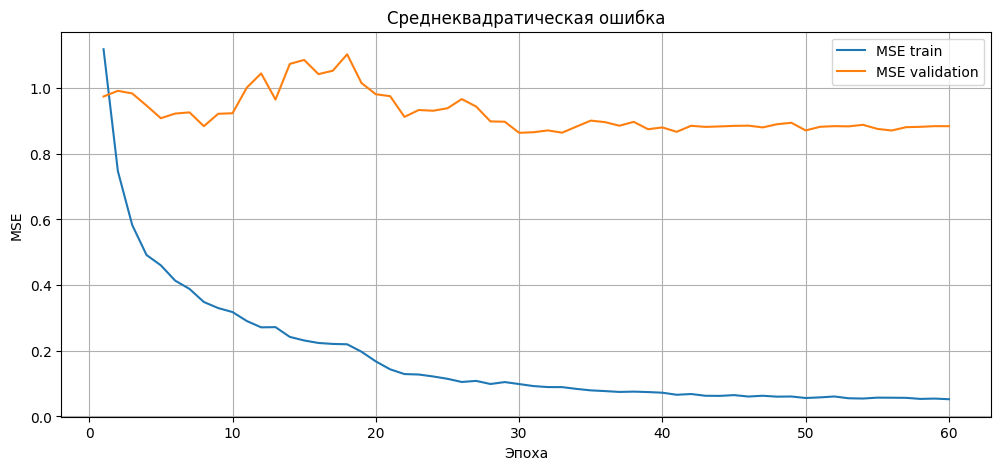

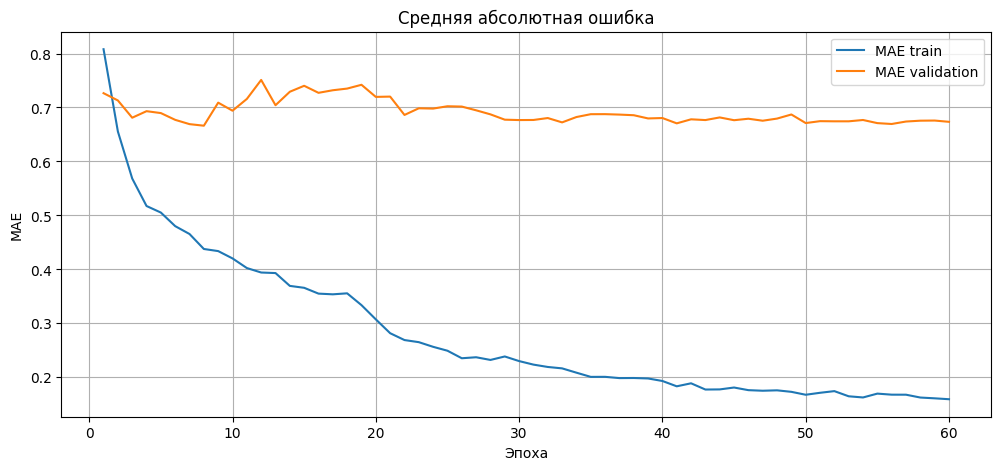

Средняя процентная ошибка VALIDATION: 26.88%
Средняя абсолютная ошибка VALIDATION: 213.62
Результат >= 10% — базовое условие выполнено, модель можно улучшать дальше.
Средняя процентная ошибка TEST: 26.91%
Средняя абсолютная ошибка TEST: 236.97


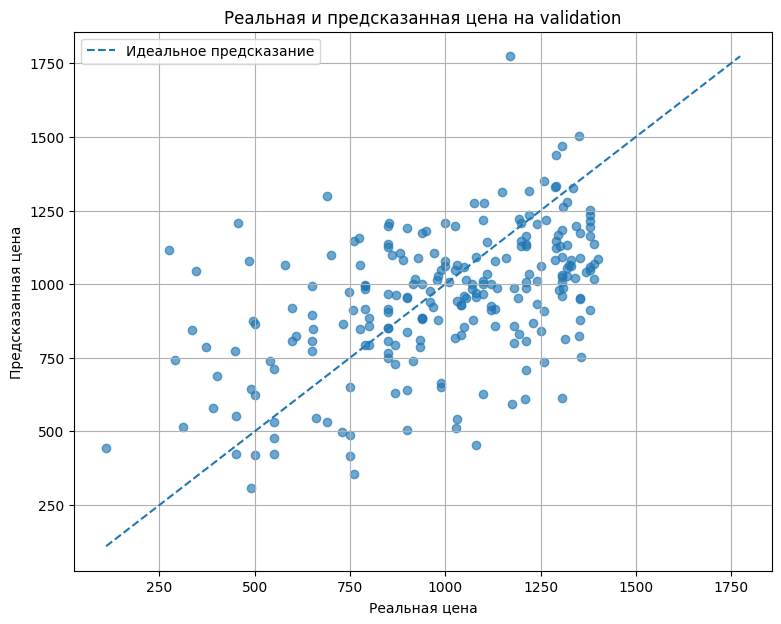

,mark,model,year,mileage,engine_capacity,real_price,predicted_price,error_percent
779,toyota,fun cargo,2001,94444,1300,850.0,851.428467,0.168055
796,suzuki,swift,2004,77000,1320,850.0,851.478882,0.173986
611,honda,fit,2007,45000,1300,790.0,792.839905,0.359482
1178,toyota,vitz,2007,127000,1300,1010.0,1006.251770,0.371112
2118,toyota,allion,2003,84469,1500,1334.0,1326.847168,0.536194
1259,suzuki,alto,2005,107000,660,1049.0,1058.098389,0.867339
1652,toyota,ist,2005,55186,1300,1198.0,1208.902710,0.910076
682,mitsubishi,minicab van,2013,119700,660,800.0,792.365723,0.954285
1336,toyota,sienta,2005,158000,1500,1080.0,1091.930908,1.104714
1754,toyota,vitz,2007,107000,1290,1220.0,1233.894775,1.138916


In [1]:


# Импорт библиотек
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

# Инструменты sklearn для разбиения и подготовки данных
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Слои и колбэки Keras
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.regularizers import l2


# Фиксируем случайность, чтобы результаты были более воспроизводимыми
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ===
# Прямая ссылка на датасет из задания
DATASET_URL = (
    "https://storage.yandexcloud.net/academy.ai/"
    "japan_cars_dataset.csv"
)

# pandas читает CSV непосредственно по URL
df = pd.read_csv(DATASET_URL)

print("Размер датасета:", df.shape)

# Посмотрим первые строки
display(df.head())

# Посмотрим названия колонок и типы данных
df.info()

# ===
unnamed_columns = [
    column
    for column in df.columns
    if column.lower().startswith("unnamed")
]

if unnamed_columns:
    df = df.drop(columns=unnamed_columns)


# Удаляем полные дубликаты, если они присутствуют
df = df.drop_duplicates().reset_index(drop=True)


# Проверяем пропущенные значения
print("Пропуски:")
display(
    df.isna().sum().sort_values(
        ascending=False
    )
)


# Если пропусков немного, удаляем такие строки
df = df.dropna().reset_index(drop=True)


# Цена должна быть положительной
df = df[
    df["price"] > 0
].reset_index(drop=True)


print("Размер после очистки:", df.shape)

display(
    df.describe(
        include="all"
    ).T
)

# ===
def add_features(data, reference_year):
    # Создаём копию, чтобы не менять исходный DataFrame
    data = data.copy()

    # Возраст автомобиля относительно максимального года в train
    data["car_age"] = (
        reference_year - data["year"]
    ).clip(lower=0)

    # Логарифм пробега уменьшает влияние очень больших значений
    data["log_mileage"] = np.log1p(
        data["mileage"].clip(lower=0)
    )

    # Средний пробег на один год эксплуатации
    data["mileage_per_year"] = (
        data["mileage"]
        / (data["car_age"] + 1)
    )

    # Связка марки и модели помогает сети различать
    # конкретные модели внутри одной марки
    data["mark_model"] = (
        data["mark"].astype(str)
        + "__"
        + data["model"].astype(str)
    )

    return data

# ===
# X — входные признаки автомобиля
X = df.drop(
    columns=["price"]
)

# y — цена, которую должна предсказывать модель
y = df["price"].astype(
    np.float32
)


# Отделяем 10% для финального test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=SEED,
)


# Из оставшихся 90% выделяем 1/9.
# 1/9 от 90% = 10% от всего датасета.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=1 / 9,
    random_state=SEED,
)


print("TRAIN:", X_train.shape, y_train.shape)
print("VAL:  ", X_val.shape, y_val.shape)
print("TEST: ", X_test.shape, y_test.shape)


# Максимальный год определяем только по обучающей выборке
REFERENCE_YEAR = int(
    X_train["year"].max()
)

print("REFERENCE_YEAR:", REFERENCE_YEAR)

# ===
# Добавляем одинаковые инженерные признаки во все три выборки.
# REFERENCE_YEAR при этом всегда взят только из train.
X_train = add_features(
    X_train,
    REFERENCE_YEAR,
)

X_val = add_features(
    X_val,
    REFERENCE_YEAR,
)

X_test = add_features(
    X_test,
    REFERENCE_YEAR,
)

display(X_train.head())

# ===
# Категориальные признаки
categorical_columns = [
    "mark",
    "model",
    "transmission",
    "drive",
    "hand_drive",
    "fuel",
    "mark_model",
]


# Числовые признаки
numeric_columns = [
    "year",
    "mileage",
    "engine_capacity",
    "car_age",
    "log_mileage",
    "mileage_per_year",
]


# Проверяем структуру датасета
missing_columns = [
    column
    for column in (
        categorical_columns
        + numeric_columns
    )
    if column not in X_train.columns
]

if missing_columns:
    raise ValueError(
        "В датасете отсутствуют ожидаемые колонки: "
        + ", ".join(missing_columns)
    )


# ColumnTransformer применяет разные преобразования к числовым и категориальным колонкам
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_columns,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_columns,
        ),
    ],
    remainder="drop",
)


# fit_transform выполняется только на train.
X_train_ready = preprocessor.fit_transform(
    X_train
).astype(np.float32)


# Validation и test не участвуют в обучении преобразователя
X_val_ready = preprocessor.transform(
    X_val
).astype(np.float32)

X_test_ready = preprocessor.transform(
    X_test
).astype(np.float32)


print(
    "После кодирования:",
    X_train_ready.shape,
    X_val_ready.shape,
    X_test_ready.shape,
)

# Переводим цену в логарифмическую шкалу
y_train_log = np.log1p(
    y_train.to_numpy().reshape(-1, 1)
)

y_val_log = np.log1p(
    y_val.to_numpy().reshape(-1, 1)
)

y_test_log = np.log1p(
    y_test.to_numpy().reshape(-1, 1)
)


# Нормализуем целевую переменную по аналогии с уроком
y_scaler = StandardScaler()


# Обучаем scaler только на train
y_train_scaled = y_scaler.fit_transform(
    y_train_log
).astype(np.float32)


# Validation и test только преобразуем
y_val_scaled = y_scaler.transform(
    y_val_log
).astype(np.float32)

y_test_scaled = y_scaler.transform(
    y_test_log
).astype(np.float32)


print(
    "Среднее y_train_scaled:",
    y_train_scaled.mean(),
)

print(
    "Std y_train_scaled:",
    y_train_scaled.std(),
)

# Число входных признаков после кодирования
INPUT_SIZE = X_train_ready.shape[1]


model = Sequential(
    [
        # Входной вектор признаков
        Input(
            shape=(INPUT_SIZE,)
        ),

        # Первый крупный слой
        Dense(
            512,
            activation="relu",
            kernel_regularizer=l2(1e-5),
        ),

        BatchNormalization(),
        Dropout(0.10),

        # Постепенно уменьшаем размерность представления
        Dense(
            256,
            activation="relu",
            kernel_regularizer=l2(1e-5),
        ),

        BatchNormalization(),
        Dropout(0.10),

        Dense(
            128,
            activation="relu",
        ),

        BatchNormalization(),

        Dense(
            64,
            activation="relu",
        ),

        # Один выходной нейрон для предсказания цены
        Dense(1),
    ]
)


# По условию задания используем MSE
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=["mae"],
)


model.summary()

BEST_MODEL_PATH = (
    "/content/best_japan_cars.keras"
)


# Сохраняем модель с минимальной ошибкой на validation
checkpoint = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1,
)


# Останавливаем обучение, если улучшения долго нет
early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=30,
    verbose=1,
)


# Постепенно уменьшаем learning rate, когда val_loss перестаёт улучшаться
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1,
)


history = model.fit(
    X_train_ready,
    y_train_scaled,

    # Явно передаём проверочную выборку
    validation_data=(
        X_val_ready,
        y_val_scaled,
    ),

    epochs=300,
    batch_size=32,
    shuffle=True,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr,
    ],

    verbose=1,
)

# ===
epochs_range = range(
    1,
    len(history.history["loss"]) + 1,
)


# График MSE
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    epochs_range,
    history.history["loss"],
    label="MSE train",
)

plt.plot(
    epochs_range,
    history.history["val_loss"],
    label="MSE validation",
)

plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Среднеквадратическая ошибка")
plt.grid()
plt.legend()
plt.show()


# График MAE
plt.figure(
    figsize=(12, 5)
)

plt.plot(
    epochs_range,
    history.history["mae"],
    label="MAE train",
)

plt.plot(
    epochs_range,
    history.history["val_mae"],
    label="MAE validation",
)

plt.xlabel("Эпоха")
plt.ylabel("MAE")
plt.title("Средняя абсолютная ошибка")
plt.grid()
plt.legend()
plt.show()

# Загружаем лучшую модель, а не просто последнюю эпоху
best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH
)


# Прогноз в нормализованной логарифмической шкале
val_prediction_scaled = best_model.predict(
    X_val_ready,
    verbose=0,
)


# Отменяем StandardScaler
val_prediction_log = y_scaler.inverse_transform(
    val_prediction_scaled
)


# Отменяем log1p
val_prediction = np.expm1(
    val_prediction_log
).reshape(-1)


# Реальные цены validation
val_real = y_val.to_numpy()


# Цена не должна быть отрицательной
val_prediction = np.maximum(
    val_prediction,
    0,
)


# Процентная ошибка для каждого автомобиля
val_percentage_errors = (
    np.abs(
        val_real - val_prediction
    )
    / val_real
    * 100
)


#===
val_mean_percentage_error = np.mean(
    val_percentage_errors
)


# Дополнительно считаем абсолютную ошибку в единицах цены
val_mae_price = np.mean(
    np.abs(
        val_real - val_prediction
    )
)


print(
    f"Средняя процентная ошибка VALIDATION: "
    f"{val_mean_percentage_error:.2f}%"
)

print(
    f"Средняя абсолютная ошибка VALIDATION: "
    f"{val_mae_price:.2f}"
)


# Проверяем критерии оценки задания
if val_mean_percentage_error < 5:
    print(
        "Результат < 5% — условие на 5 баллов выполнено."
    )

elif val_mean_percentage_error < 10:
    print(
        "Результат < 10% — условие на 4 балла выполнено."
    )

else:
    print(
        "Результат >= 10% — базовое условие выполнено, "
        "модель можно улучшать дальше."
    )

# ===
# Прогноз test
test_prediction_scaled = best_model.predict(
    X_test_ready,
    verbose=0,
)


# Возвращаемся к реальным ценам
test_prediction_log = y_scaler.inverse_transform(
    test_prediction_scaled
)

test_prediction = np.expm1(
    test_prediction_log
).reshape(-1)

test_prediction = np.maximum(
    test_prediction,
    0,
)


test_real = y_test.to_numpy()


# Процентная ошибка на независимом test
test_percentage_error = np.mean(
    np.abs(
        test_real - test_prediction
    )
    / test_real
    * 100
)


test_mae_price = np.mean(
    np.abs(
        test_real - test_prediction
    )
)


print(
    f"Средняя процентная ошибка TEST: "
    f"{test_percentage_error:.2f}%"
)

print(
    f"Средняя абсолютная ошибка TEST: "
    f"{test_mae_price:.2f}"
)

# ===
plt.figure(
    figsize=(9, 7)
)

plt.scatter(
    val_real,
    val_prediction,
    alpha=0.65,
)


# Диагональная линия идеального предсказания
minimum = min(
    val_real.min(),
    val_prediction.min(),
)

maximum = max(
    val_real.max(),
    val_prediction.max(),
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    label="Идеальное предсказание",
)

plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.title(
    "Реальная и предсказанная цена на validation"
)
plt.grid()
plt.legend()
plt.show()

# ===
# Создаём таблицу для наглядного сравнения
comparison = X_val.copy()

comparison["real_price"] = val_real
comparison["predicted_price"] = val_prediction
comparison["error_percent"] = val_percentage_errors


display(
    comparison[
        [
            "mark",
            "model",
            "year",
            "mileage",
            "engine_capacity",
            "real_price",
            "predicted_price",
            "error_percent",
        ]
    ]
    .sort_values(
        "error_percent"
    )
    .head(20)
)
